In [ ]:
# Can not mount to google drive
# not enough space
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()  # This restarts the runtime automatically

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:06
🔁 Restarting kernel...


In [ ]:
! conda create -n dna python=3.8

In [ ]:
! conda env list


# conda environments:
#
base                   /usr/local
dna                    /usr/local/envs/dna



In [ ]:
! git clone https://github.com/MAGICS-LAB/DNABERT_2.git

Cloning into 'DNABERT_2'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 129 (delta 33), reused 20 (delta 20), pack-reused 82 (from 1)
Receiving objects: 100% (129/129), 880.73 KiB | 13.14 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [ ]:
%cd /content/DNABERT_2/

/content/DNABERT_2


In [ ]:
import transformers
print(transformers.__version__)
# check the system transformers version, should be 5.0

5.0.0


In [ ]:
# install torch, because it is slow
!conda run -n dna pip install torch==1.13.1 --timeout 600

In [ ]:
# 先在 dna 环境装正确版本, SUCCEED
!conda run -n dna pip install -r requirements.txt --timeout 300

In [ ]:
%%writefile /content/check_env.py
import torch
import transformers
import peft
print('torch:', torch.__version__)
print('transformers:', transformers.__version__)
print('peft:', peft.__version__)

Writing /content/check_env.py


In [ ]:
!conda run -n dna python /content/check_env.py

torch: 1.13.1+cu117
transformers: 4.29.2
peft: 0.3.0



In [ ]:
%%writefile /content/dna_script.py
import torch
from transformers import AutoTokenizer, AutoModel, AutoConfig

tokenizer = AutoTokenizer.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)
config = AutoConfig.from_pretrained("zhihan1996/DNABERT-2-117M", trust_remote_code=True)

if not hasattr(config, 'pad_token_id') or config.pad_token_id is None:
    if tokenizer.pad_token_id is not None:
        config.pad_token_id = tokenizer.pad_token_id

model = AutoModel.from_pretrained(
    "zhihan1996/DNABERT-2-117M",
    trust_remote_code=True,
    config=config,
    low_cpu_mem_usage=False,
    device_map=None
)
print("Model loaded successfully!")

dna = "ACGTAGCATCGGATCTATCTATCGACACTTGGTTATCGATCTACGAGCATCTCGTTAGC"
inputs = tokenizer(dna, return_tensors = 'pt')["input_ids"]
hidden_states = model(inputs)[0] # [1, sequence_length, 768]

# embedding with mean pooling
embedding_mean = torch.mean(hidden_states[0], dim=0)
print("embedding_mean: ", embedding_mean.shape) # expect to be 768

# embedding with max pooling
embedding_max = torch.max(hidden_states[0], dim=0)[0]
print("embedding_max: ", embedding_max.shape) # expect to be 768

Writing /content/dna_script.py


In [ ]:
!conda run -n dna python /content/dna_script.py

Model loaded successfully!
embedding_mean:  torch.Size([768])
embedding_max:  torch.Size([768])

/usr/local/envs/dna/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- configuration_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- flash_attn_triton.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded

In [ ]:
%cd /content/DNABERT_2/finetune/

/content/DNABERT_2/finetune


In [ ]:
! ls

scripts  train.py


#Finetune on CPU

In [ ]:
import gdown
!gdown "https://drive.google.com/drive/folders/1f5oQ-h6T47KEzQJ0oeR-3qEnukV3osne" --folder

Retrieving folder contents
Processing file 15X8-vmjxULJ1icGgCYaagAiRj3vCptTE dev.csv
Processing file 1vHG-mpC2fkvHSn17fNMeI33Glimja-EY test.csv
Processing file 19_DA3iYg1sqTNs_arRq5qOJGrTVLYH-w train.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=15X8-vmjxULJ1icGgCYaagAiRj3vCptTE
To: /content/DNABERT_2/finetune/input/dev.csv
100% 7.94M/7.94M [00:00<00:00, 227MB/s]
Downloading...
From: https://drive.google.com/uc?id=1vHG-mpC2fkvHSn17fNMeI33Glimja-EY
To: /content/DNABERT_2/finetune/input/test.csv
100% 15.9M/15.9M [00:00<00:00, 158MB/s]
Downloading...
From: https://drive.google.com/uc?id=19_DA3iYg1sqTNs_arRq5qOJGrTVLYH-w
To: /content/DNABERT_2/finetune/input/train.csv
100% 55.6M/55.6M [00:00<00:00, 215MB/s]
Download completed


In [ ]:
# create folder to save checkpoint
! mkdir output

In [ ]:
%%writefile /content/run_train.sh
#!/bin/bash

export DATA_PATH=/content/DNABERT_2/sample_data
export MAX_LENGTH=100
export LR=3e-5

python /content/DNABERT_2/finetune/train.py \
    --model_name_or_path zhihan1996/DNABERT-2-117M \
    --data_path ${DATA_PATH} \
    --kmer -1 \
    --run_name DNABERT2_${DATA_PATH} \
    --model_max_length ${MAX_LENGTH} \
    --per_device_train_batch_size 8 \
    --per_device_eval_batch_size 16 \
    --gradient_accumulation_steps 1 \
    --learning_rate ${LR} \
    --num_train_epochs 5 \
    --save_steps 200 \
    --output_dir /content/DNABERT_2/finetune/output \
    --evaluation_strategy steps \
    --eval_steps 200 \
    --warmup_steps 50 \
    --logging_steps 100 \
    --overwrite_output_dir True \
    --log_level info \
    --find_unused_parameters False

Writing /content/run_train.sh


In [ ]:
!conda run -n dna bash /content/run_train.sh

{'train_runtime': 53.1934, 'train_samples_per_second': 1.41, 'train_steps_per_second': 0.188, 'train_loss': 0.6706323623657227, 'epoch': 5.0}

/usr/local/envs/dna/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/root/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT-2-117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
Some weights of the model checkpoint at zhihan1996/DNABERT-2-117M were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.pred

# Training use DistributedDataParallel (more efficient)
### A100 GPU ~80 faster

In [ ]:
# cp input from google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


cp -r drive/MyDrive/input_order/ DNABERT_2/finetune/
    4  ls
    5  cd DNABERT_2/
    6  ls
    7  cd finetune/
    8  ls
    9  cd input_order/
   11  mv eval_EP_DNA_BERT2_genomic_order.csv dev.csv
   12  mv train_EP_DNA_BERT2_genomic_order.csv train.csv
   13  mv test_EP_DNA_BERT2_genomic_order.csv test.csv
   14  ls
   15  cd ..
   16  mkdir output

In [ ]:
# 2. 验证 GPU 可用
import torch
print(torch.cuda.is_available())      # 应该是 True
print(torch.cuda.get_device_name(0))  # 显示 GPU 型号

True
NVIDIA A100-SXM4-40GB


In [ ]:
%%writefile /content/run_train_gpu.sh
#!/bin/bash
export DATA_PATH=/content/DNABERT_2/sample_data
export MAX_LENGTH=100
export LR=3e-5
export num_gpu=1 # 1 A100 GPU is enough

conda run -n dna torchrun --nproc_per_node=1 /content/DNABERT_2/finetune/train.py --model_name_or_path zhihan1996/DNABERT-2-117M --data_path ${DATA_PATH} --kmer -1 --run_name DNABERT2 --model_max_length ${MAX_LENGTH} --per_device_train_batch_size 8 --per_device_eval_batch_size 16 --gradient_accumulation_steps 1 --learning_rate ${LR} --num_train_epochs 5 --fp16 --save_steps 200 --output_dir /content/DNABERT_2/finetune/output --evaluation_strategy steps --eval_steps 200 --warmup_steps 50 --logging_steps 100 --overwrite_output_dir True --log_level info --find_unused_parameters False

Overwriting /content/run_train_gpu.sh


In [ ]:
! conda run -n dna bash /content/run_train_gpu.sh

{'train_runtime': 1.4999, 'train_samples_per_second': 50.003, 'train_steps_per_second': 6.667, 'train_loss': 0.6947605609893799, 'epoch': 5.0}


/usr/local/envs/dna/lib/python3.8/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/root/.cache/huggingface/modules/transformers_modules/zhihan1996/DNABERT-2-117M/7bce263b15377fc15361f52cfab88f8b586abda0/bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
Some weights of the model checkpoint at zhihan1996/DNABERT-2-117M were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.bias', 'cls.pr

# GPU finetune with our data, original version from Github
copy data into local SSD /content 10x faster than google drive

In [ ]:
%%writefile /content/run_train_gpu_large.sh
#!/bin/bash
export DATA_PATH=/content/DNABERT_2/finetune/input_shuffled
export MAX_LENGTH=75
export LR=3e-5
export num_gpu=1 # 1 A100 GPU is enough

conda run -n dna torchrun --nproc_per_node=1 /content/DNABERT_2/finetune/train.py --model_name_or_path zhihan1996/DNABERT-2-117M --data_path ${DATA_PATH} --kmer -1 --run_name DNABERT2 --model_max_length ${MAX_LENGTH} --per_device_train_batch_size 8 --per_device_eval_batch_size 16 --gradient_accumulation_steps 1 --learning_rate ${LR} --num_train_epochs 5 --fp16 --save_steps 200 --output_dir /content/DNABERT_2/finetune/output --evaluation_strategy steps --eval_steps 200 --warmup_steps 50 --logging_steps 100 --overwrite_output_dir True --log_level info --find_unused_parameters False

Overwriting /content/run_train_gpu_large.sh


In [ ]:
! conda run -n dna bash /content/run_train_gpu_large.sh

# Faster version, change the batch_size and eval frequency. If run the large input, could run 2-3 hours, compare to original 20 hours.

In [ ]:
%%writefile /content/run_train_gpu_large_fast.sh
#!/bin/bash
export DATA_PATH=/content/DNABERT_2/finetune/input_order
export MAX_LENGTH=75
export LR=3e-5 # 1e-5
export num_gpu=1 # 1 A100 GPU is enough

torchrun --nproc_per_node=1 /content/DNABERT_2/finetune/train.py \
    --model_name_or_path zhihan1996/DNABERT-2-117M \
    --data_path ${DATA_PATH} \
    --kmer -1 \
    --run_name DNABERT2 \
    --model_max_length ${MAX_LENGTH} \
    --per_device_train_batch_size 32 \
    --per_device_eval_batch_size 64 \
    --gradient_accumulation_steps 1 \
    --learning_rate ${LR} \
    --num_train_epochs 3 \
    --bf16 \
    --save_steps 1000 \
    --output_dir /content/DNABERT_2/finetune/output \
    --evaluation_strategy steps \
    --eval_steps 1000 \
    --warmup_steps 500 \
    --logging_steps 200 \
    --overwrite_output_dir True \
    --log_level info \
    --find_unused_parameters False \
    --dataloader_num_workers 4 \
    --load_best_model_at_end True \
    --metric_for_best_model eval_matthews_correlation \
    --greater_is_better True \
    --save_total_limit 3 \

Writing /content/run_train_gpu_large_fast.sh


In [ ]:
! conda run -n dna bash /content/run_train_gpu_large_fast.sh

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [ ]:
import pandas as pd
df = pd.read_csv('/content/DNABERT_2/finetune/input_shuffled/dev.csv')
print(df['label'].value_counts(normalize=True))

label
0    0.500462
1    0.499538
Name: proportion, dtype: float64


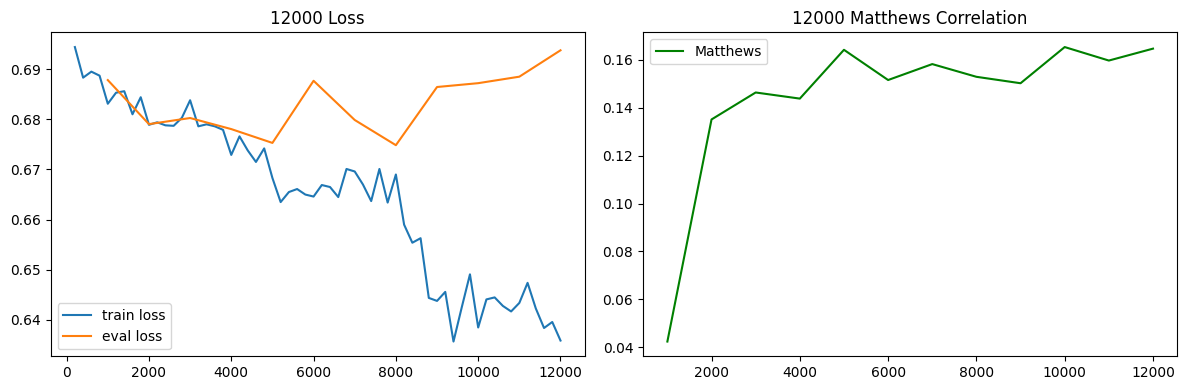

In [ ]:
import json
import matplotlib.pyplot as plt

with open("/content/DNABERT_2/finetune/output/checkpoint-12000/trainer_state.json") as f:
    state = json.load(f)

train_loss = [(x["step"], x["loss"]) for x in state["log_history"] if "loss" in x]
eval_loss  = [(x["step"], x["eval_loss"]) for x in state["log_history"] if "eval_loss" in x]
eval_mcc   = [(x["step"], x["eval_matthews_correlation"]) for x in state["log_history"] if "eval_matthews_correlation" in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(*zip(*train_loss), label="train loss")
ax1.plot(*zip(*eval_loss), label="eval loss")
ax1.set_title("12000 Loss")
ax1.legend()

ax2.plot(*zip(*eval_mcc), color="green", label="Matthews")
ax2.set_title("12000 Matthews Correlation")
ax2.legend()

plt.tight_layout()
plt.savefig("/content/training_curve.png")
plt.show()

In [ ]:
from google.colab import files
#files.download("/content/DNABERT_2/finetune/output/results/DNABERT2/eval_results.json")
files.download("/content/training_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 先打包成 zip
!zip -r /content/dnabert2_model.zip /content/DNABERT_2/finetune/output/

# 再下载
from google.colab import files
files.download("/content/dnabert2_model.zip")

  adding: content/DNABERT_2/finetune/output/ (stored 0%)
  adding: content/DNABERT_2/finetune/output/checkpoint-11000/ (stored 0%)
  adding: content/DNABERT_2/finetune/output/checkpoint-11000/rng_state.pth (deflated 28%)
  adding: content/DNABERT_2/finetune/output/checkpoint-11000/pytorch_model.bin


zip error: Interrupted (aborting)


FileNotFoundError: Cannot find file: /content/dnabert2_model.zip